In [3]:
import numpy as np
import matplotlib.pyplot as plt
import copy
import math

In [4]:
def load_data():
    data = np.loadtxt("data/ex1data1.txt", delimiter=',')
    X = data[:,0]
    y = data[:,1]
    return X, y

In [5]:
# load the dataset
x_train, y_train = load_data()

In [6]:
# print x_train
print("Type of x_train:",x_train.dtype)
print("First ten elements of x_train are:\n", x_train[:10])

Type of x_train: float64
First ten elements of x_train are:
 [6.1101 5.5277 8.5186 7.0032 5.8598 8.3829 7.4764 8.5781 6.4862 5.0546]


In [7]:
# print y_train
print("Type of y_train:",y_train.dtype)
print("First ten elements of y_train are:\n", y_train[:10])

Type of y_train: float64
First ten elements of y_train are:
 [17.592   9.1302 13.662  11.854   6.8233 11.886   4.3483 12.      6.5987
  3.8166]


In [8]:
print ('The shape of x_train is:', x_train.shape)
print ('The shape of y_train is: ', y_train.shape)
print ('Number of training examples (m):', len(x_train))

The shape of x_train is: (97,)
The shape of y_train is:  (97,)
Number of training examples (m): 97


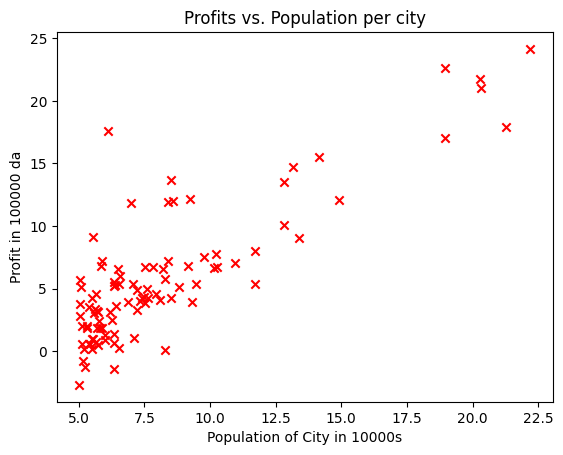

In [9]:
# Create a scatter plot of the data. To change the markers to red "x",
# we used the 'marker' and 'c' parameters
plt.scatter(x_train, y_train, marker='x', c='r')

# Set the title
plt.title("Profits vs. Population per city")
# Set the y-axis label
plt.ylabel('Profit in 100000 da')
# Set the x-axis label
plt.xlabel('Population of City in 10000s')
plt.show()

## EXO1 ##

In [10]:
def compute_cost(x, y, w, b):
    # number of training examples
    m = x.shape[0]
    total_cost = 0

    ### Vectorization ##
    # 1. Compute the predictions for all examples using vectorized operations.
    y_predict = w*x + b
    # 2. Compute the errors (difference between predictions and actual labels).
    e = y_predict - y
    # 3. Square the errors.
    e = e**2
    # 4. Sum the squared errors and divide by (2*m) to compute the cost.
    total_cost = e.sum() / (2*m)

    ### normal loop ##
    # for i in range(m):
    #     y_predict = w*x[i] + b
    #     e = y_predict - y[i]
    #     se = e**2
    #     total_cost += se
    # total_cost = total_cost / (2*m)

    return total_cost

## TEST EXO1 ## 

In [ ]:
# Compute cost with some initial values for paramaters w, b
initial_w = 2
initial_b = 1

cost = compute_cost(x_train, y_train, initial_w, initial_b)
print(type(cost))
print(f'Cost at initial w: {cost:.3f}')

# Public tests
from public_tests import *
compute_cost_test(compute_cost)

<class 'numpy.float64'>
Cost at initial w: 75.203
All tests passed!


## EXO2 ##

In [12]:
def compute_gradient(x, y, w, b):
    # Number of training examples
    m = x.shape[0]

    ### START CODE HERE ##
    # Steps:
    # 1. Compute the predictions for all examples using vectorized operations.
    y_predict = w*x + b
    # 2. Compute the errors (difference between predictions and actual labels).
    e = y_predict - y
    # 3. Compute dj_dw as the mean of (errors * x).
    dj_dw = np.dot(x,e) / m
    # 4. Compute dj_db as the mean of errors.
    dj_db = e.sum() / m
    ### END CODE HERE ###

    return dj_dw, dj_db

## TEST EXO2 ##

In [13]:
# Compute and display gradient with w initialized to zeroes
initial_w = 0
initial_b = 0

tmp_dj_dw, tmp_dj_db = compute_gradient(x_train, y_train, initial_w, initial_b)
print('Gradient at initial w, b (zeros):', tmp_dj_dw, tmp_dj_db)

Gradient at initial w, b (zeros): -65.3288497455567 -5.839135051546393


In [14]:
# Compute and display cost and gradient with non-zero w
test_w = 0.2
test_b = 0.2
tmp_dj_dw, tmp_dj_db = compute_gradient(x_train, y_train, test_w, test_b)

print('Gradient at test w, b:', tmp_dj_dw, tmp_dj_db)

Gradient at test w, b: -47.416101181144334 -4.007175051546392


## EXO3 ##

In [15]:
def gradient_descent(x, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters):
    # number of training examples
    m = len(x)

    # An array to store cost J and w's at each iteration — primarily for graphing later
    J_history = []
    w_history = []
    w = copy.deepcopy(w_in)  #avoid modifying global w within function
    b = b_in

    for i in range(num_iters):

        ## START STUDENT CODE ##
        # Calculate the gradient and update the parameters
        dj_dw, dj_db = gradient_function(x, y, w, b)
        # Update Parameters using w, b, alpha, and gradients
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        ## END STUDENT CODE ##

        # Save cost J at each iteration
        if i<100000:      # prevent resource exhaustion
            cost =  cost_function(x, y, w, b)
            J_history.append(cost)

        # Print cost every at intervals 100
        if (i+1) % 100 == 0:
            w_history.append(w)
            # print(f"Iteration {i+1:4}: Cost {float(J_history[-1]):8.2f}   ")

    return w, b, J_history, w_history #return w and J,w history for graphing

## TEST EXO3 ##

In [16]:
# initialize fitting parameters. Recall that the shape of w is (n,)
initial_w = 0.5
initial_b = 0.5

# some gradient descent settings
iterations = 1500
alpha = 0.024

w,b,J_history,_ = gradient_descent(x_train ,y_train, initial_w, initial_b,compute_cost, compute_gradient, alpha, iterations)
print("w,b found by gradient descent:", w, b)

w,b found by gradient descent: 1.192368224211408 -3.889157203524523


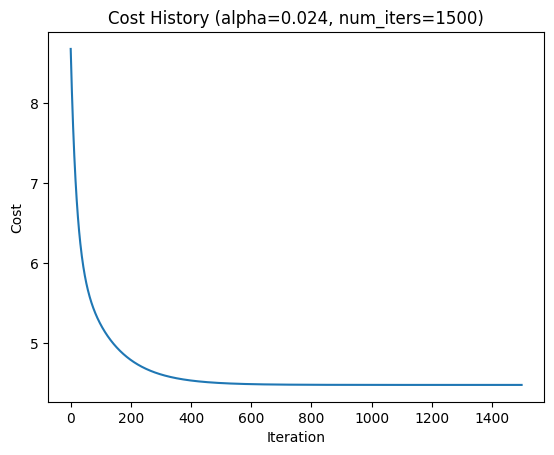

In [17]:
# Plot the cost history
plt.plot(J_history)
plt.title(f"Cost History (alpha={alpha}, num_iters={iterations})")
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.show()

Text(0.5, 0, 'Population of City in 10000s')

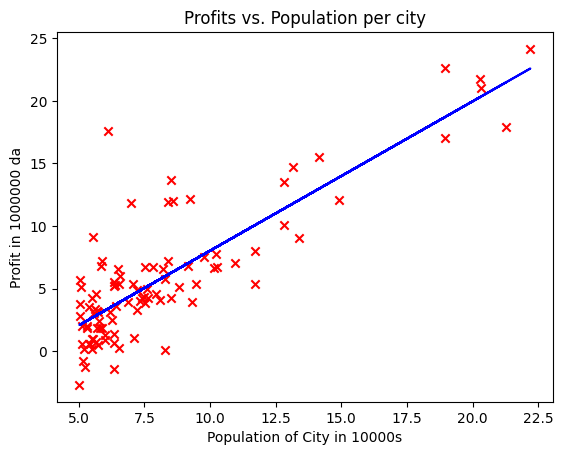

In [18]:
# predicted = np.dot(x_train, w) + b
predicted = w * x_train + b

# Plot the linear fit
plt.plot(x_train, predicted, c = "b")

# Create a scatter plot of the data.
plt.scatter(x_train, y_train, marker='x', c='r')

# Set the title
plt.title("Profits vs. Population per city")
# Set the y-axis label
plt.ylabel('Profit in 1000000 da')
# Set the x-axis label
plt.xlabel('Population of City in 10000s')

# Exercise 4: Experimenting with Hyperparameters

### _1 test gradient descent : 

3. **Answer the Following Questions:**
* What happens if the learning rate is too small? Too large?
* **answer** : too small : very small step + slow convergence | very large step + overshoots the minimum + may diverge
* How does the number of iterations affect the final values of w and b?
* **answer** : depending on the number of iterations , the gradient descent may not reach the best w and b values, so the cost may not reach its minimum
* Do the initial values of w and b impact the final result? Why or why not?
* **answer** : the initial values of w and b affects the intial cost value where the gradient descent starts descending from and the convergence speed , will it affect the result ? it depends on the iterations and learning rate


# EXO5

In [19]:
from sklearn.linear_model import LinearRegression

In [35]:
x_train = x_train.reshape(-1, 1)

In [22]:
model = LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [30]:
w = model.coef_[0]
b = model.intercept_

print("w =", w)
print("b =", b)

w = 1.1930336441895937
b = -3.895780878311852


In [33]:
y_pred = model.predict(x_train)
print(y_pred)

[ 3.39377399  2.6989512   6.26719552  4.45927234  3.09515767  6.10530086
  5.02381586  6.33818102  3.84247394  2.13452698  2.91727635 13.00234766
  2.94507404  6.13572322  2.833764    2.52202431  3.69835548  2.22460102
  3.77494824  4.53992141  3.48802365 20.28701109  2.65409313  3.65146926
  2.74333205 18.70624151 11.40845471  9.17628876 11.82363042 22.59314512
  2.37050903  3.96559502  7.13763287  3.13333475  5.90033768  5.56903223
  5.7629002   2.79272364 11.41799898  3.68403908  2.55483273  4.31527318
 10.07225703  2.99243747  5.43934948  4.56652606  2.1531383   3.02548451
 10.06271276  2.71553436  5.09993141  2.43648379  4.96118159  5.17497322
  3.65946258  3.69060076  3.58955081  2.83257096  7.21160096  7.38268198
  6.63321825  2.28329828 21.49078204 13.88996469 18.72294398  4.71577457
  6.0005525   8.3161115   2.66518834 20.37171648  8.19680814  4.85452438
  3.2698178   4.72496093  2.10147995  3.91608412  5.09802255  2.11293307
  8.36144678  2.19787707  2.93934748  2.29415488  3

In [34]:
model.score(x_train, y_train)

0.7020315537841397

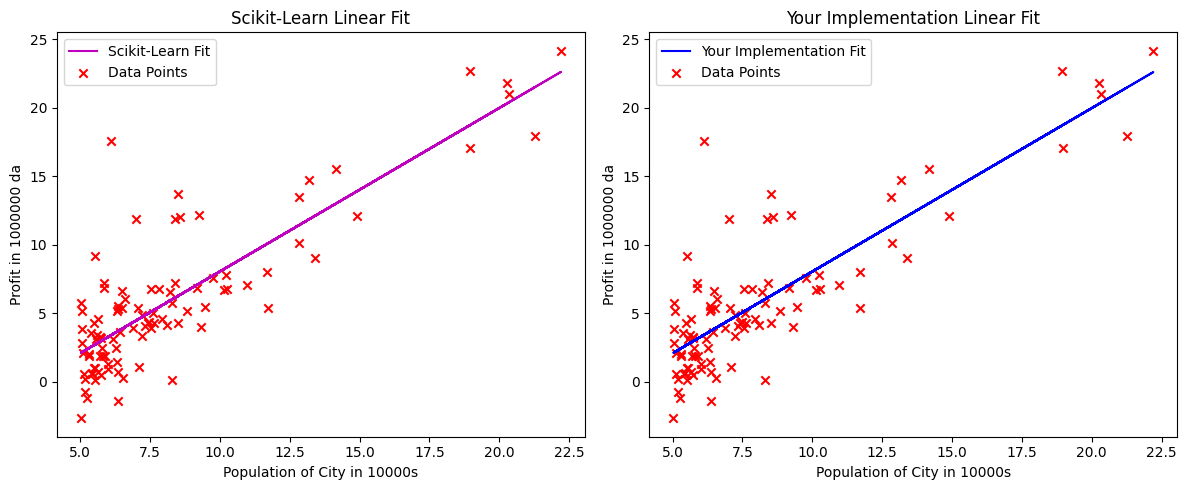

In [37]:
# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns

# Plot 1: Scikit-Learn Linear Fit
ax1.plot(x_train, y_pred, c="m", label="Scikit-Learn Fit")  # Plot Scikit-Learn predictions
ax1.scatter(x_train, y_train, marker='x', c='r', label="Data Points")  # Scatter plot of data
ax1.set_title("Scikit-Learn Linear Fit")  # Set title
ax1.set_ylabel('Profit in 1000000 da')  # Set y-axis label
ax1.set_xlabel('Population of City in 10000s')  # Set x-axis label
ax1.legend()  # Add legend

# Plot 2: Your Implementation Linear Fit
ax2.plot(x_train, predicted, c="b", label="Your Implementation Fit")  # Plot your predictions
ax2.scatter(x_train, y_train, marker='x', c='r', label="Data Points")  # Scatter plot of data
ax2.set_title("Your Implementation Linear Fit")  # Set title
ax2.set_ylabel('Profit in 1000000 da')  # Set y-axis label
ax2.set_xlabel('Population of City in 10000s')  # Set x-axis label
ax2.legend()  # Add legend

# Display the plots
plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()